# FOGAS Hyperoptimizer Boxplots

Summary plots for the saved FOGAS hyperoptimization CSVs across `2State`, `3Grid`, and `3Grid Wall`.

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for parent in [start, *start.parents]:
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return start


PROJECT_ROOT = find_project_root()
RESULTS_ROOT = PROJECT_ROOT / "data" / "results"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RESULTS_ROOT:  {RESULTS_ROOT}")

PROJECT_ROOT: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
RESULTS_ROOT:  /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results


In [32]:
PROBLEMS = ["2State", "3Grid", "3Grid Wall"]
BASE_HYPERPARAMETERS = ["alpha", "rho", "eta", "D_theta"]
HYPERPARAMETERS = [*BASE_HYPERPARAMETERS, "eta_rho"]

PARAMETER_LABELS = {
    "alpha": "alpha",
    "rho": "rho",
    "eta": "eta",
    "eta_rho": "eta * rho",
    "D_theta": "D theta",
}

PROBLEM_COLORS = {
    "2State": "#cfe8ff",
    "3Grid": "#d9f2d0",
    "3Grid Wall": "#ffe4c7",
}

ORACLE_CSVS = {
    "2State": RESULTS_ROOT / "2states" / "oracle_search.csv",
    "3Grid": RESULTS_ROOT / "3grid" / "oracle.csv",
    "3Grid Wall": RESULTS_ROOT / "3grid_wall" / "oracle.csv",
}

EMPIRICAL_TABULAR_CSVS = {
    "2State": RESULTS_ROOT / "2states" / "empirical_tab.csv",
    "3Grid": RESULTS_ROOT / "3grid" / "empirical_tabular.csv",
    "3Grid Wall": RESULTS_ROOT / "3grid_wall" / "empirical_tab.csv",
}

EMPIRICAL_FEATURE_CSVS = {
    "2State": RESULTS_ROOT / "2states" / "empirical_funky.csv",
    "3Grid": RESULTS_ROOT / "3grid" / "empirical_agg4.csv",
    "3Grid Wall": RESULTS_ROOT / "3grid_wall" / "empirical_agg.csv",
}

RESULT_GROUPS = {
    "Oracle": ORACLE_CSVS,
    "Empirical Tabular": EMPIRICAL_TABULAR_CSVS,
    "Empirical Feature Approx.": EMPIRICAL_FEATURE_CSVS,
}


In [33]:
def load_result(csv_path, metric_column="metric"):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

    df = pd.read_csv(csv_path)
    required = {metric_column, *BASE_HYPERPARAMETERS}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {missing}")

    df = df.copy()
    df["eta_rho"] = df["eta"] * df["rho"]

    return df


def sorted_parameter_values(df, parameter):
    values = df[parameter].dropna().unique()
    return sorted(values, key=float)


def boxplot_for_parameter(ax, df, parameter, metric_column="metric", box_color=None):
    keys = sorted_parameter_values(df, parameter)
    grouped = df[[parameter, metric_column]].dropna().groupby(parameter)
    data = [grouped.get_group(key)[metric_column].to_numpy() for key in keys]
    labels = [f"{float(key):g}" for key in keys]

    boxplot_kwargs = {"showmeans": True, "patch_artist": True}
    try:
        box = ax.boxplot(data, tick_labels=labels, **boxplot_kwargs)
    except TypeError:
        box = ax.boxplot(data, labels=labels, **boxplot_kwargs)

    if box_color is not None:
        for patch in box["boxes"]:
            patch.set_facecolor(box_color)
            patch.set_edgecolor("#555555")
            patch.set_alpha(0.85)
        for median in box["medians"]:
            median.set_color("#222222")

    ax.set_xlabel(PARAMETER_LABELS.get(parameter, parameter))
    ax.set_ylabel("Solver avg reward")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)


def load_group_results(result_groups=RESULT_GROUPS):
    return {
        group_name: {
            problem: load_result(path)
            for problem, path in csv_map.items()
        }
        for group_name, csv_map in result_groups.items()
    }


def validate_all_csvs(result_groups=RESULT_GROUPS):
    for group_name, csv_map in result_groups.items():
        print(f"\n{group_name}")
        for problem, path in csv_map.items():
            df = load_result(path)
            print(f"  {problem:10s} | {len(df):4d} rows | {path}")


def plot_parameter_boxplot_grid(parameter, metric_column="metric"):
    if parameter not in HYPERPARAMETERS:
        raise ValueError(f"Unknown hyperparameter: {parameter}")

    loaded = load_group_results()
    group_names = list(RESULT_GROUPS.keys())
    parameter_label = PARAMETER_LABELS.get(parameter, parameter)

    fig, axes = plt.subplots(
        len(group_names),
        len(PROBLEMS),
        figsize=(16, 10),
        squeeze=False,
    )
    fig.suptitle(
        f"{parameter_label} Hyperoptimization Boxplots",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    for row_idx, group_name in enumerate(group_names):
        for col_idx, problem in enumerate(PROBLEMS):
            ax = axes[row_idx, col_idx]
            df = loaded[group_name][problem]
            boxplot_for_parameter(
                ax,
                df,
                parameter,
                metric_column=metric_column,
                box_color=PROBLEM_COLORS.get(problem),
            )
            ax.set_title(f"{group_name} - {problem}", fontsize=11)

    plt.tight_layout()
    plt.show()


In [34]:
validate_all_csvs()



Oracle
  2State     |  750 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/2states/oracle_search.csv
  3Grid      |  875 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/3grid/oracle.csv
  3Grid Wall |  875 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/3grid_wall/oracle.csv

Empirical Tabular
  2State     |  750 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/2states/empirical_tab.csv
  3Grid      |  750 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/3grid/empirical_tabular.csv
  3Grid Wall |  750 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/3grid_wall/empirical_tab.csv

Empirical Feature Approx.
  2State     |  450 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/2states/empirical_funky.csv
  3Grid      |  750 rows | /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/3grid/empirical_agg4.csv
  3Grid Wall |  750 rows | /home/mauro/Desktop/EM

## alpha


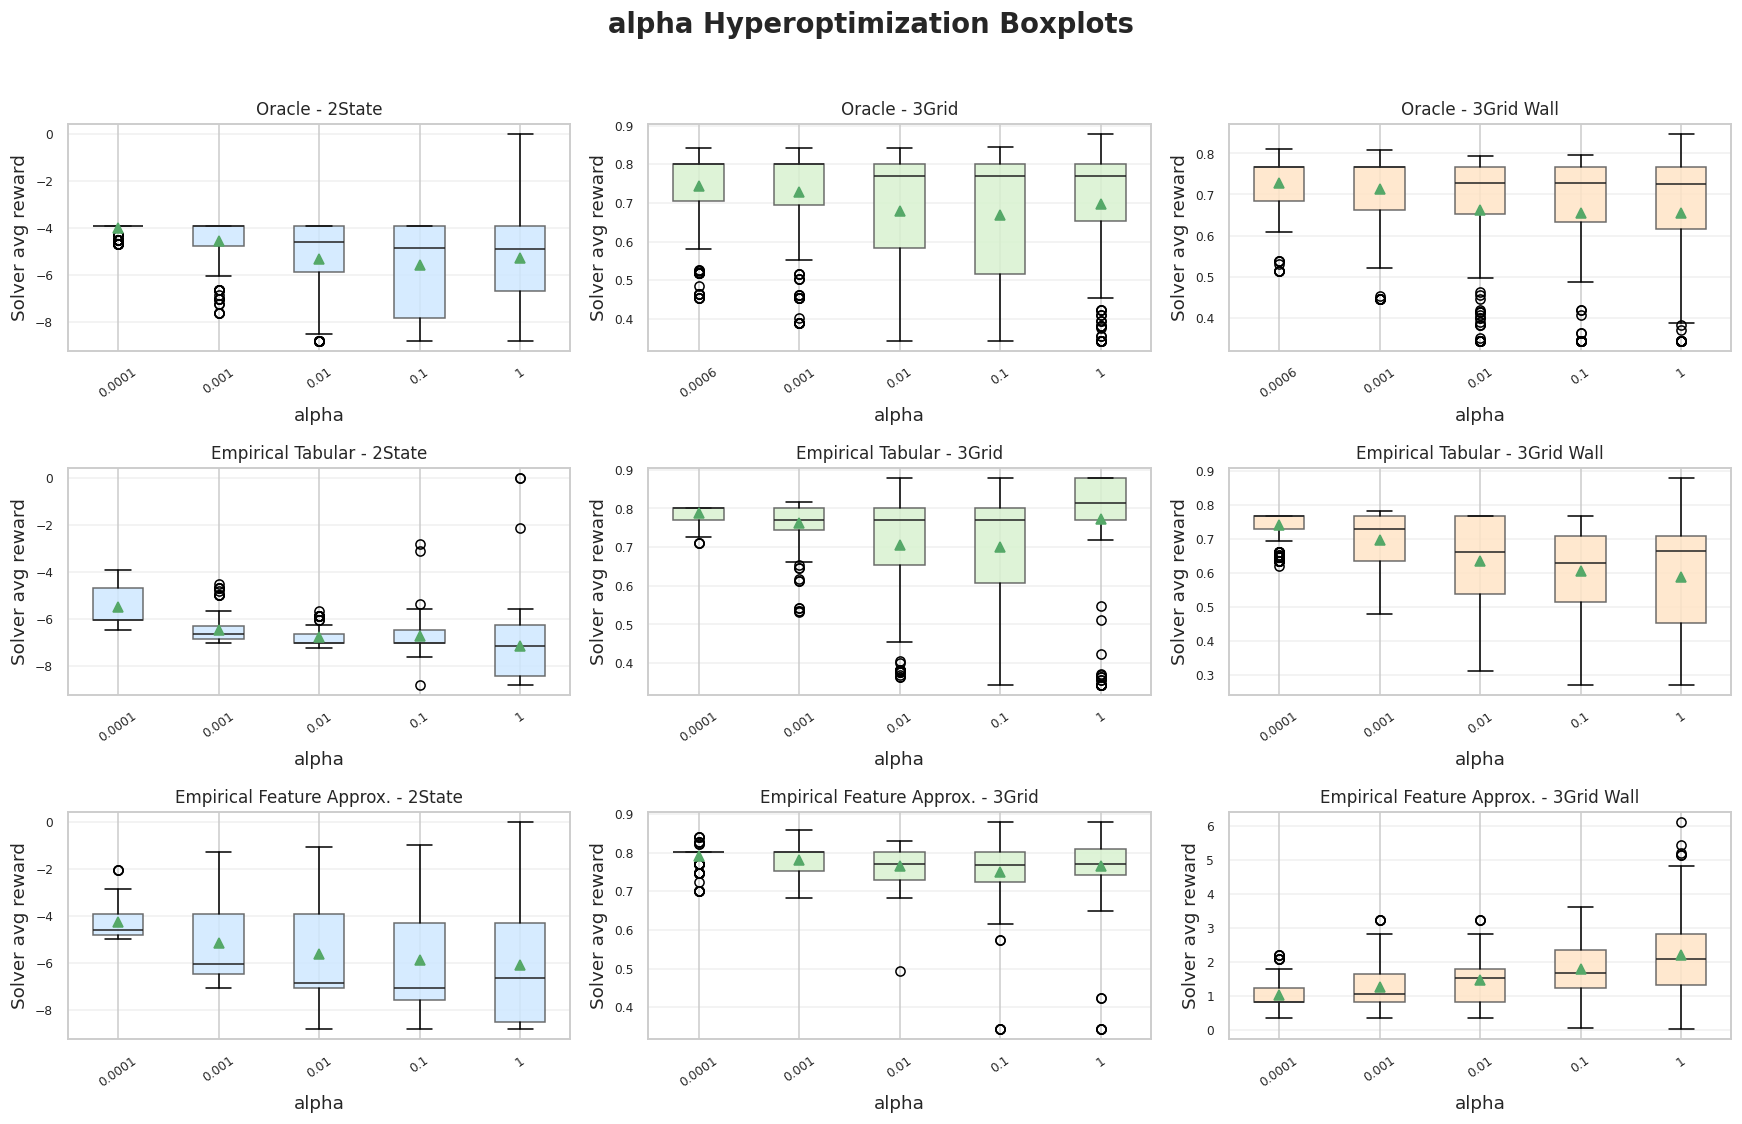

In [35]:
plot_parameter_boxplot_grid("alpha")


## rho


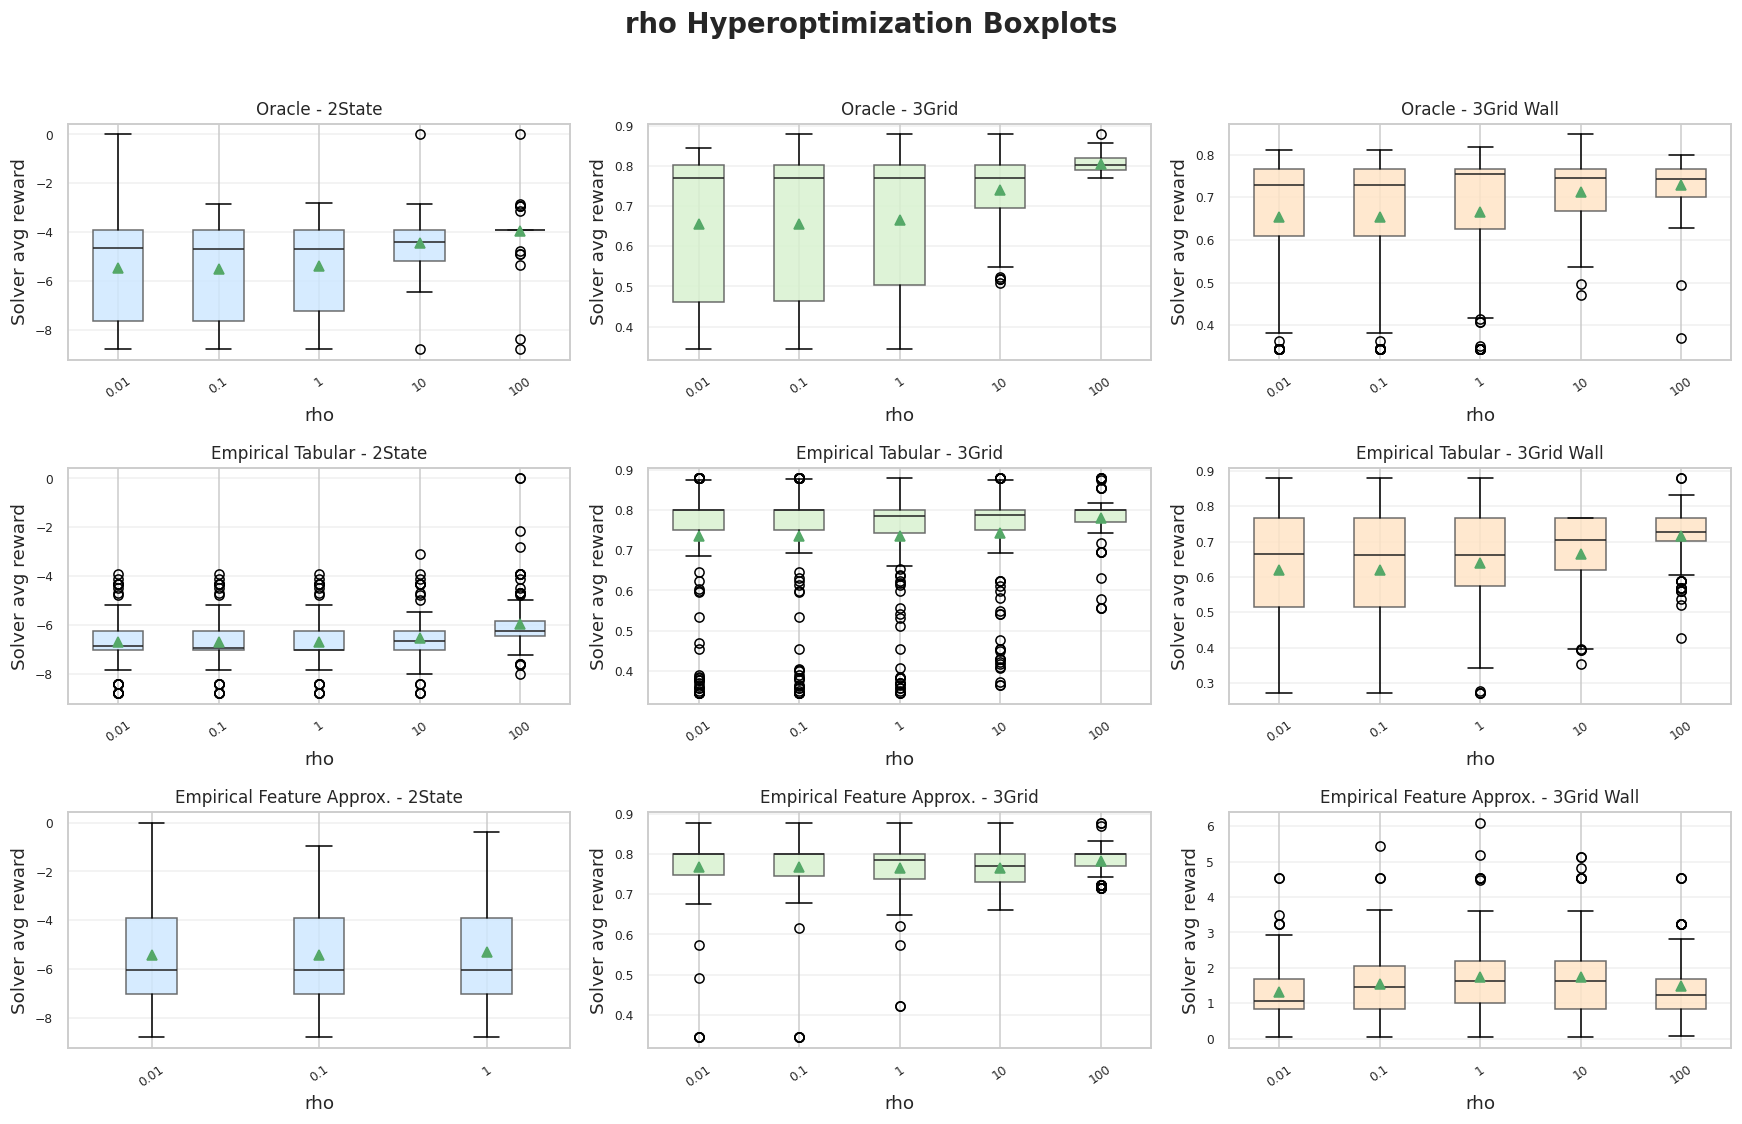

In [36]:
plot_parameter_boxplot_grid("rho")


## eta


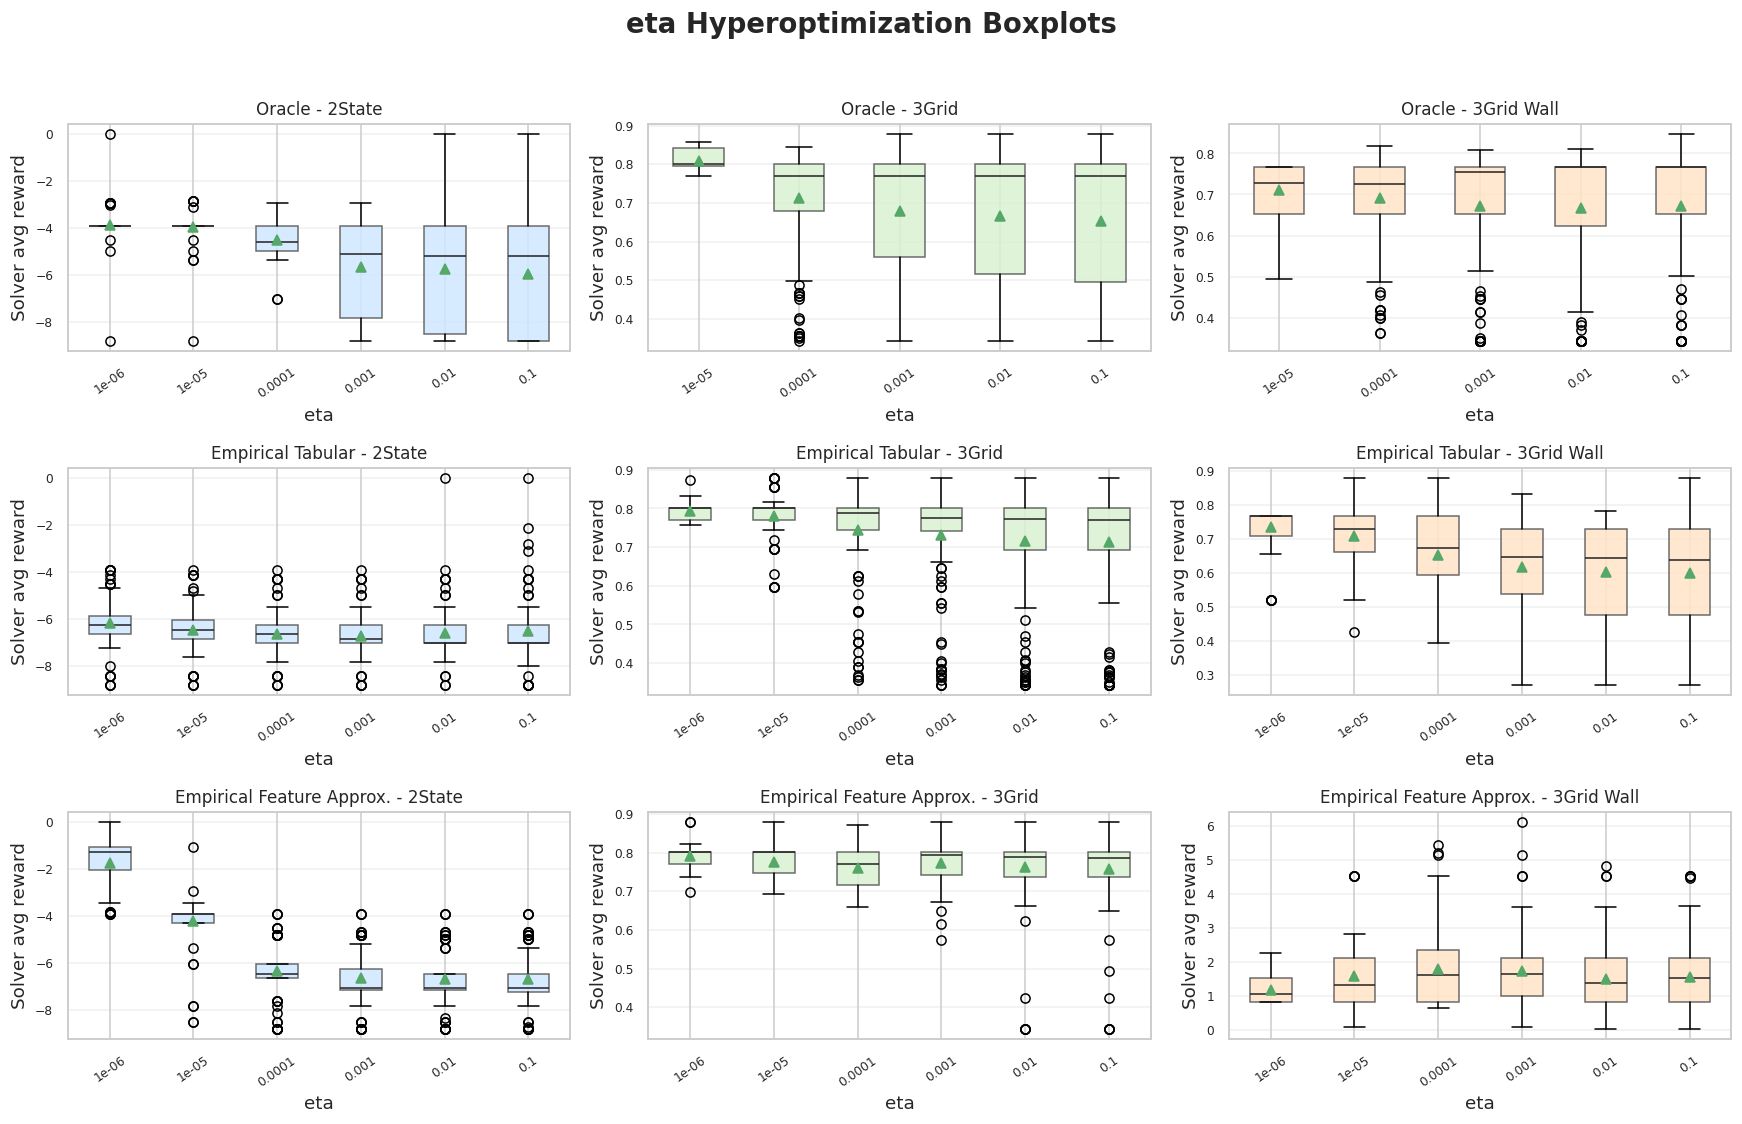

In [37]:
plot_parameter_boxplot_grid("eta")


## eta * rho


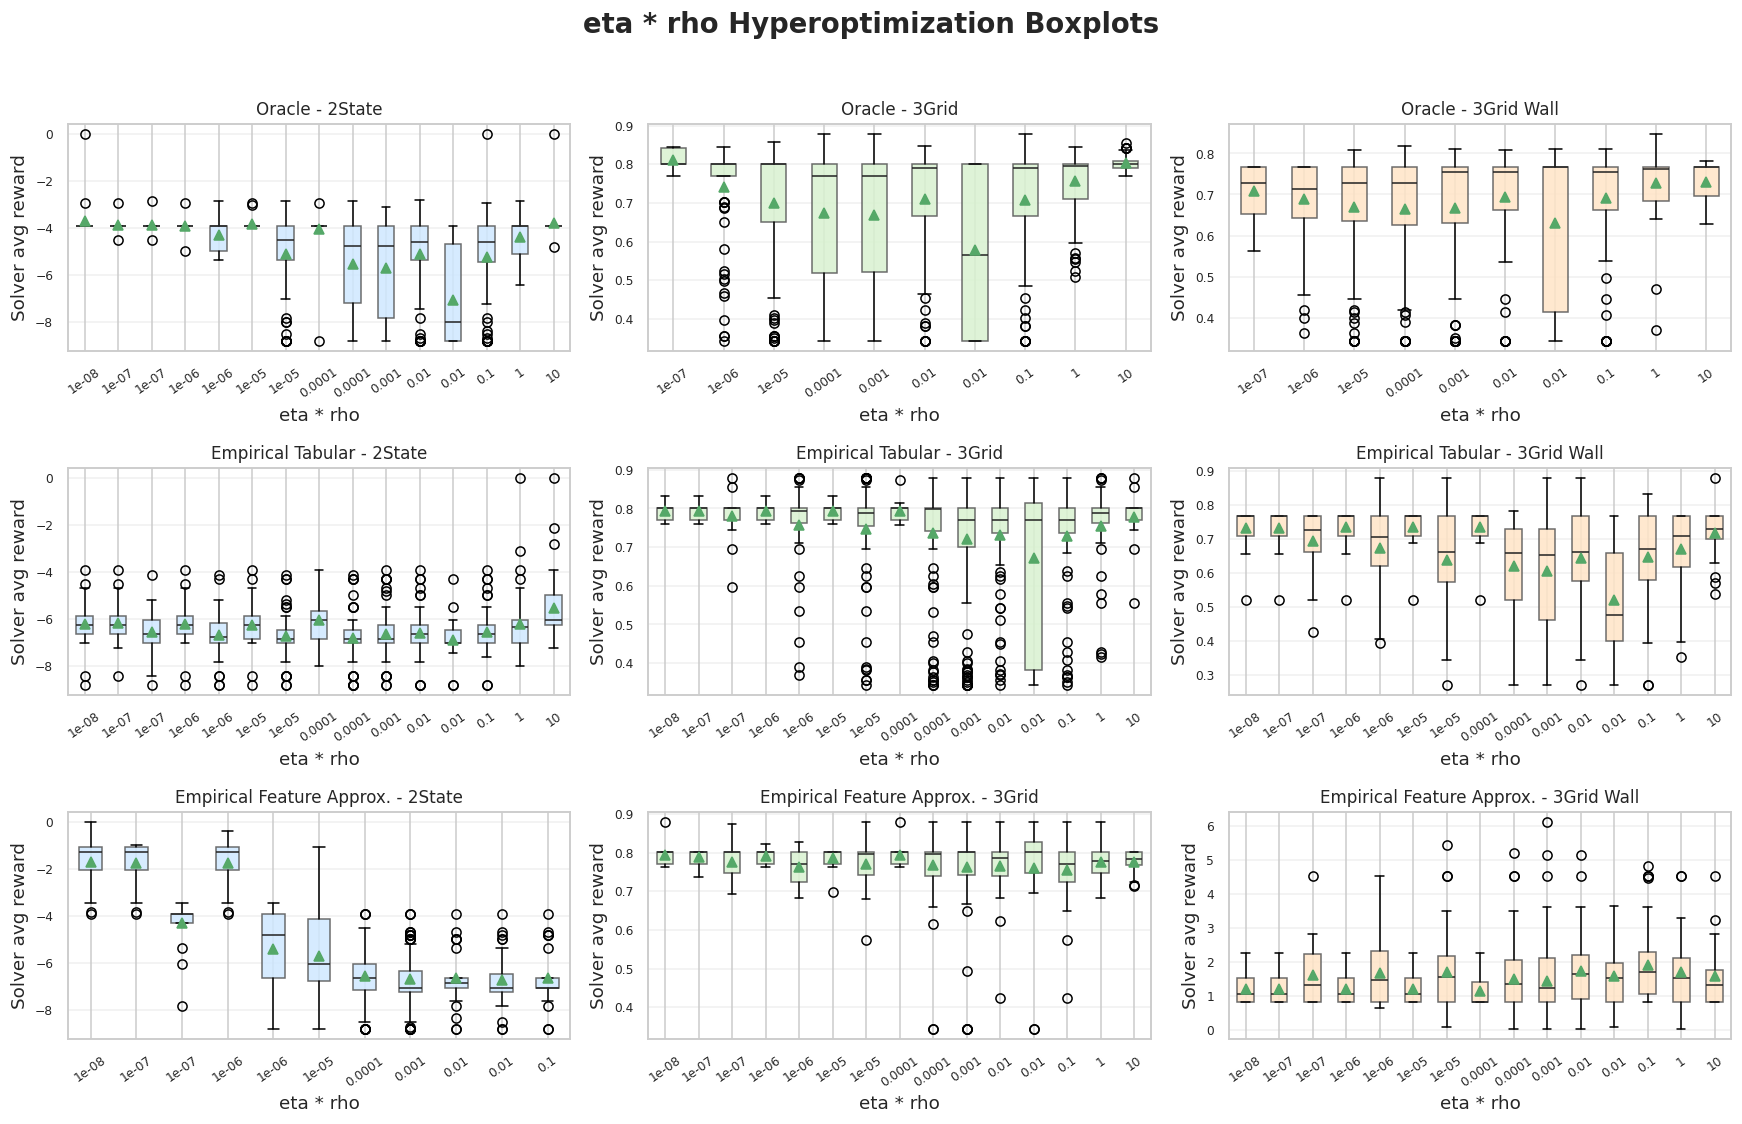

In [38]:
plot_parameter_boxplot_grid("eta_rho")


## D theta


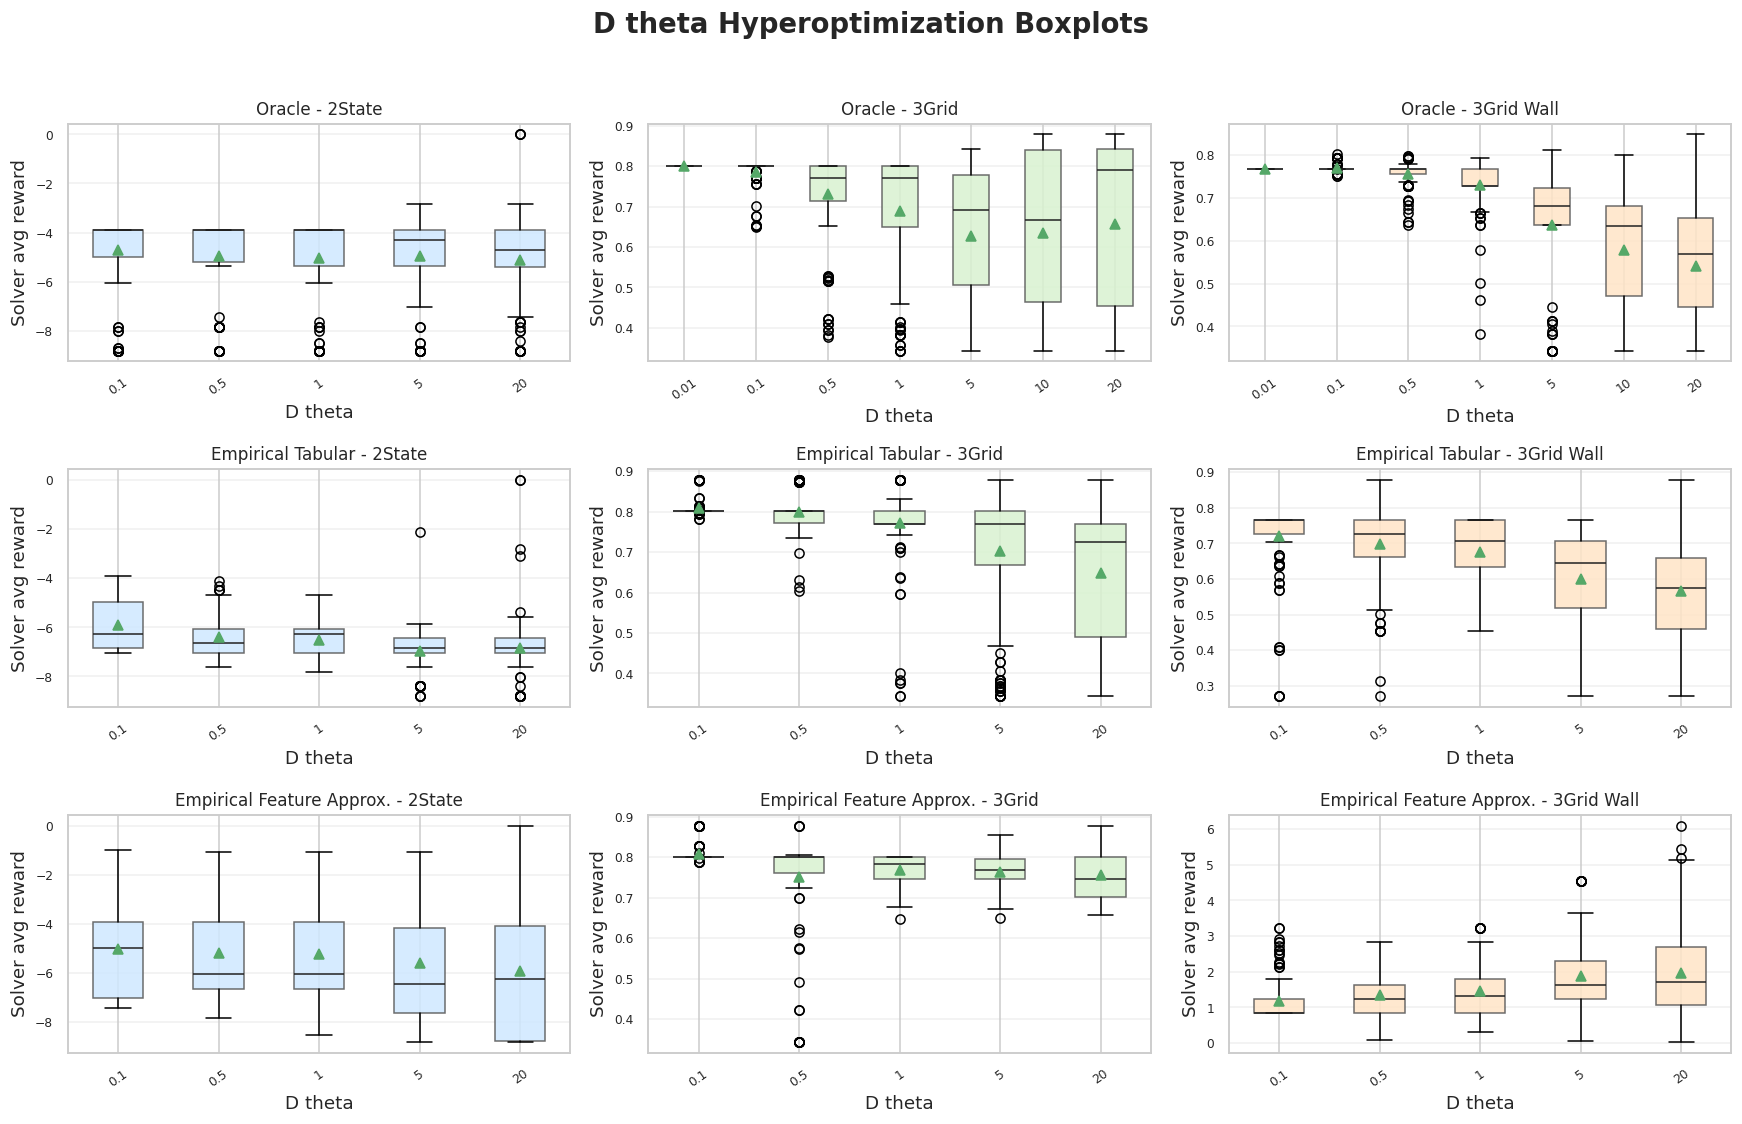

In [39]:
plot_parameter_boxplot_grid("D_theta")
